A script for making spatial firing plots for chosen cells
- compare firing in explore and homing
- show a few cells making a pattern in homing and being all over in explore
- show the firing in homing and explore colored by hdir

In [31]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from behave_analysis.visualize.efizz.heatmap import assign_positional_bins_to_frames
from behave_analysis.utils.heatplot_utils import filter_outside_arena_tracking_for_video_and_spike_data
from JR_test_scripts.escape.escape_utils import load_homing
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
import matplotlib.gridspec as gridspec
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
from behave_analysis.visualize.behaviour.behavioral_stats import hsv_hdir_colormap

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from loguru import logger
import dill as pickle
from pathlib import Path

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
"""Load the data"""
exp = JAL6_flip4_21mar
session_name = "JAL6_flip4_21mar"
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]

In [32]:
"""Load data"""
# load session
session = Process(exp).load_session()

# load hdir cells
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)

# load video & spike data
COLUMNS_TO_KEEP = [
    "mouse_x_position",
    "mouse_y_position",
    "spike_clusters",
    "spike_count",
    "OutofshelterIdx",
    "EscapePeriod",
    "shelter",
    "barrier_present",
    "barrier_flipped",
    "hdir",
    "homingPeriod", # 'homingPeriod'
]
base_path = os.path.join(session.base_path, session.processed_path)
video_and_spike_data = pl.read_parquet(
                os.path.join(base_path + "\\" + "good_video_spike_count_df.parquet"), 
                low_memory=True,
                use_pyarrow = True,
                memory_map=True,
            )

# load homings
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_and_spike_data['frames'].to_numpy()))))
if "homingPeriod" not in video_and_spike_data.columns:    
    video_and_spike_data = video_and_spike_data.with_columns(
        pl.col('frames').cast(pl.Int64).alias('frames')
    )
    homing_frames = [homing_bool[frame-1] for frame in video_and_spike_data['frames'].to_list()]
    video_and_spike_data = video_and_spike_data.hstack([pl.Series("homingPeriod", homing_frames)])

# post process video and spike data
video_and_spike_data = video_and_spike_data.select(COLUMNS_TO_KEEP)
clean_video_df = filter_outside_arena_tracking_for_video_and_spike_data(video_and_spike_data=video_and_spike_data, session=session).to_pandas()
df = pl.DataFrame(clean_video_df)

# select units of interest
unit_ids = video_and_spike_data["spike_clusters"].unique().to_numpy()
if unit_ids[0] == 0: unit_ids = unit_ids[1:]
unit_ids = unit_ids

# full x and y pos
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()

# booleans for homing+escape and explore
h_e_bool = (homing_bool | video_df['EscapePeriod'].to_numpy()) & (video_df['OutofshelterIdx'].to_numpy())
exp_bool = ((homing_bool == False) & (video_df['EscapePeriod'].to_numpy() == False)) & (video_df['OutofshelterIdx'].to_numpy())
cond = np.zeros(len(bar))
cond[bar] += 1
cond[barflip] += 1

X = x_pos[h_e_bool]
Y = y_pos[h_e_bool]
h_cond = cond[h_e_bool]

X_exp = x_pos[exp_bool]
Y_exp = y_pos[exp_bool]
exp_cond = cond[exp_bool]

2025-03-11 14:17:51.049 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [25]:
def filter_video_dataframe(dataframe, condition, outofshelter=True, behavior = 'homing'):
    """
    A function that filters the video dataframe (the behavioural data) and finds the periods of time in each condition (defined by object presence (whether the barrier or shelter is present or not))
    Time in shelter is removed
    optionally times when the mouse is escaping (x seconds after threat) are also removed
    """
    filtered_video_df = dataframe.filter((dataframe["OutofshelterIdx"] == outofshelter))

    if behavior == 'homing':
        filtered_video_df = filtered_video_df.filter((filtered_video_df["homingPeriod"] == True) | (filtered_video_df["EscapePeriod"] == True))
    elif behavior == 'exploring':
        filtered_video_df = filtered_video_df.filter((filtered_video_df["homingPeriod"] == False) & (filtered_video_df["EscapePeriod"] == False))

    if condition == "shelter_only":  # only the shelter is present (before the barrier!!)
        filtered_video_df = filtered_video_df.filter((filtered_video_df["shelter"] == True))
        if "barrier_present" in filtered_video_df.columns:
            barrier = filtered_video_df["barrier_present"].to_numpy()  # present regardless of removal
            barrier_present = np.arange(1, len(barrier) + 1) < np.where(np.diff(barrier.astype(int)) == 1)[0]
            filtered_video_df = filtered_video_df.filter((barrier_present))

    elif condition == "barrier_present":  # the hwole time the barrier is present
        filtered_video_df = filtered_video_df.filter((filtered_video_df["barrier_present"] == True))

    elif condition == "barrier_pre_flip":  # the barrier is present, before we flip it
        filtered_video_df = filtered_video_df.filter((filtered_video_df["barrier_present"] == True) & (filtered_video_df["barrier_flipped"] == False))

    elif condition == "barrier_post_flip":  # the barrier is present, after we flip it
        filtered_video_df = filtered_video_df.filter((filtered_video_df["barrier_present"] == True) & (filtered_video_df["barrier_flipped"] == True))

    return filtered_video_df

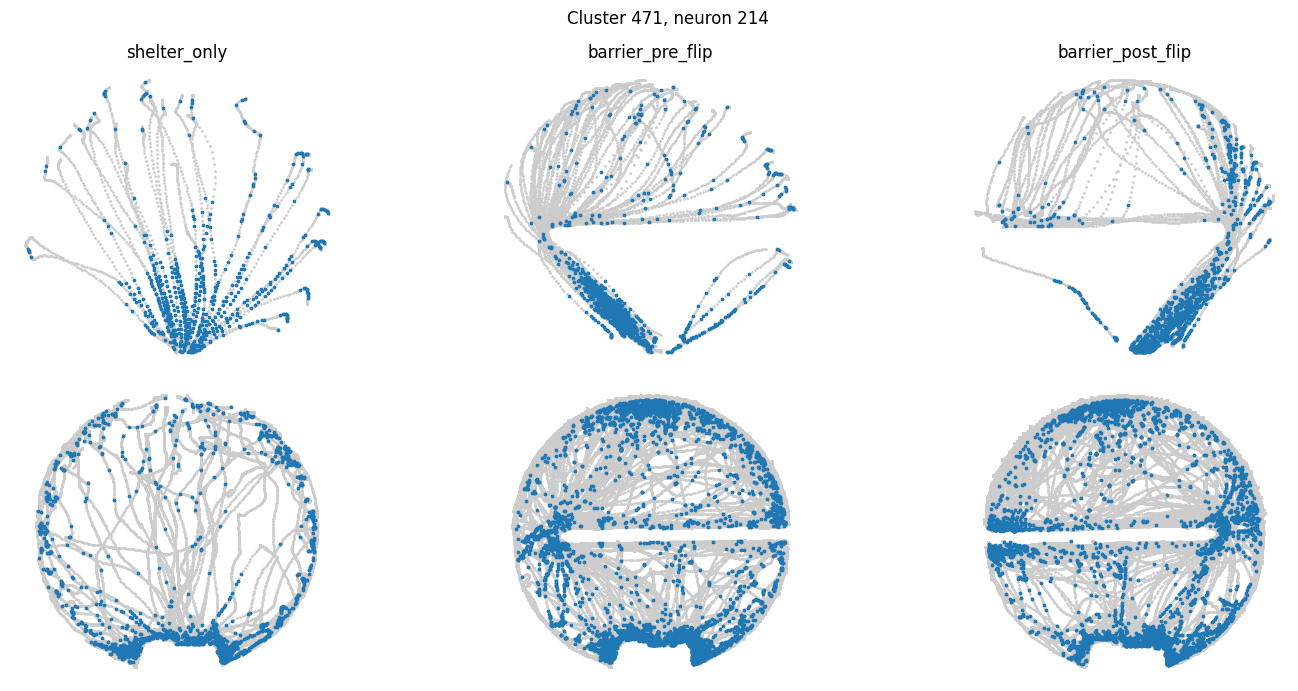

In [33]:
selected = 214 # the index of good neuron
clu = unit_ids[selected] # the KS cluster name

fig = plt.figure(figsize=(15, 7))
gs = gridspec.GridSpec(2, 4, width_ratios=[5, 5, 5, .5])
spikes = df.filter((df['spike_clusters'] == clu))

for idx, condition in enumerate(conditions):
    # make the plot for homings
    ax = fig.add_subplot(gs[0, idx])

    # plot the homing trajectories
    ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = 1)
    
    # plot the spikes
    filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
    ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                filtered_df['mouse_y_position'].to_numpy(), s = 3, c = 'C0')
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(condition)

    # make the plot for explore
    ax = fig.add_subplot(gs[1, idx])

    # plot the homing trajectories
    ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = 1)
    
    # plot the spikes
    filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
    ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                filtered_df['mouse_y_position'].to_numpy(), s = 3, c = 'C0')
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')


fig.suptitle(f'Cluster {clu}, neuron {selected}')
plt.tight_layout()

# nickname = exp.nick_name + '_' + exp.experiment_date
# exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'spatial firing'
# path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname)
# fig.savefig(path + "\\" + f'Neuron_{selected}_homingVsExplore_spatial_firing.png')
# plt.clf()
# plt.close("all")


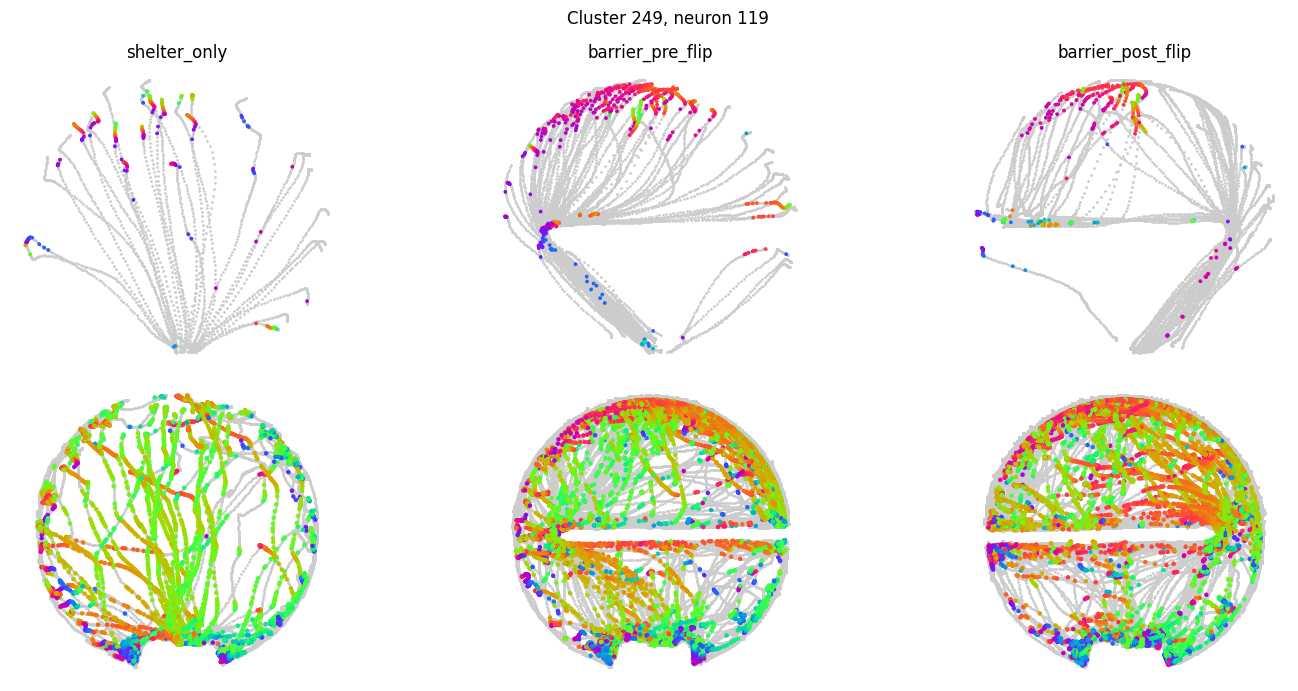

In [38]:
"""Plot spatial firing for a single neuron, but color the spikes by hdir"""
selected = 119 # the index of good neuron
clu = unit_ids[selected] # the KS cluster name

fig = plt.figure(figsize=(15, 7))
gs = gridspec.GridSpec(2, 4, width_ratios=[5, 5, 5, .5])
spikes = df.filter((df['spike_clusters'] == clu))

for idx, condition in enumerate(conditions):
    # make the plot for homings
    ax = fig.add_subplot(gs[0, idx])

    # plot the homing trajectories
    ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = 1)
    
    # plot the spikes
    filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
    hdir = np.digitize(np.rad2deg(filtered_df['hdir']), np.arange(-180, 180))
    cc = hsv_hdir_colormap(hdir)
    ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                filtered_df['mouse_y_position'].to_numpy(), s = 3, c = cc)
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(condition)

    # make the plot for explore
    ax = fig.add_subplot(gs[1, idx])

    # plot the homing trajectories
    ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = 1)
    
    # plot the spikes
    filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
    hdir = np.digitize(np.rad2deg(filtered_df['hdir']), np.arange(-180, 180))
    cc = hsv_hdir_colormap(hdir)
    ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                filtered_df['mouse_y_position'].to_numpy(), s = 5, c = cc)
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')


fig.suptitle(f'Cluster {clu}, neuron {selected}')
plt.tight_layout()

# nickname = exp.nick_name + '_' + exp.experiment_date
# exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'spatial firing'
# path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname)
# fig.savefig(path + "\\" + f'Neuron_{selected}_homingVsExplore_spatial_firing.png')
# plt.clf()
# plt.close("all")


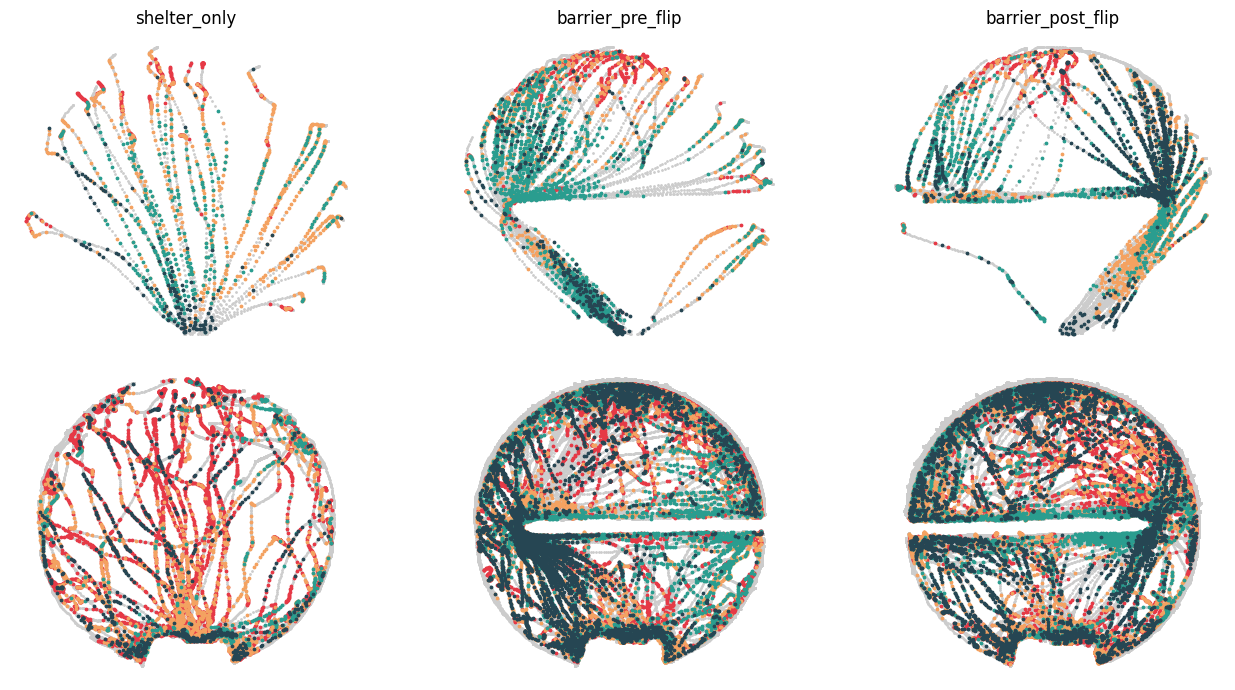

In [49]:
"""Plot the spatial firing for x neurons that make up a sequence"""

selected = [119,139,224,226,102,272] # the index of good neuron
selected = [119,224,226,102] # the index of good neuron
fig, axs = plt.subplots(2, 3, figsize=(15, 7))
colors = plt.cm.cool(np.linspace(0, 1, len(selected)))
colors = ["#E63946", "#F4A261", "#2A9D8F", "#264653"]  # Red, Orange, Teal, Dark Blue
# colors = [plt.get_cmap("tab10")(i) for i in range(4)]

for idx, condition in enumerate(conditions):
    # plot the homing trajectories
    axs[0,idx].scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = 1)
    axs[0,idx].set_axis_off()
    axs[0,idx].invert_yaxis()
    axs[0,idx].set_aspect('equal')
    axs[0,idx].set_title(condition)

    # plot the exploration behavior
    axs[1,idx].scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = 1)
    axs[1,idx].set_axis_off()
    axs[1,idx].invert_yaxis()
    axs[1,idx].set_aspect('equal')

    for n, s in enumerate(selected):
        clu = unit_ids[s] # the KS cluster name
        spikes = df.filter((df['spike_clusters'] == clu))
        # plot the homing spikes
        filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
        axs[0,idx].scatter(filtered_df['mouse_x_position'].to_numpy(),
                    filtered_df['mouse_y_position'].to_numpy(), s = 3, color = colors[n])

        # plot the exploration spikes
        filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
        axs[1,idx].scatter(filtered_df['mouse_x_position'].to_numpy(),
                    filtered_df['mouse_y_position'].to_numpy(), s = 3, color = colors[n])



# for n, s in enumerate(selected):

#     clu = unit_ids[s] # the KS cluster name
#     spikes = df.filter((df['spike_clusters'] == clu))

#     for idx, condition in enumerate(conditions):
#         # plot the homing trajectories
#         if n == 0:
#             axs[0,idx].scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = 1)
        
#         # plot the spikes
#         filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
#         axs[0,idx].scatter(filtered_df['mouse_x_position'].to_numpy(),
#                     filtered_df['mouse_y_position'].to_numpy(), s = 3, color = colors[n])
#         if n == 0:
#             axs[0,idx].set_axis_off()
#             axs[0,idx].invert_yaxis()
#             axs[0,idx].set_aspect('equal')
#             axs[0,idx].set_title(condition)

#         # plot the exploration behavior
#         axs[1,idx].scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = 1)
        
#         # plot the spikes
#         filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
#         axs[1,idx].scatter(filtered_df['mouse_x_position'].to_numpy(),
#                     filtered_df['mouse_y_position'].to_numpy(), s = 3, color = colors[n])
#         if n == 0:
#             axs[1,idx].set_axis_off()
#             axs[1,idx].invert_yaxis()
#             axs[1,idx].set_aspect('equal')

    plt.tight_layout()

    # nickname = exp.nick_name + '_' + exp.experiment_date
    # exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'spatial firing'
    # path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname)
    # fig.savefig(path + "\\" + f'Neuron_{selected}_homingVsExplore_spatial_firing.png')
    # plt.clf()
    # plt.close("all")
